# SED Spectral Model

This tutorial uses the default `BinnedSED` power law, with index fixed at -2 in every bin. Any supported astromodels spectral shape can instead be supplied through `BinnedSED.from_response(response, spectral_shape=shape)`, including a cutoff power law or a previously fitted global spectrum. By default, only the SED-bin normalizations are free; the shape parameters remain fixed unless explicitly freed by the user.

This notebook demonstrates how to perform a binned spectral energy distribution (SED) fit with COSIPy. The SED is modeled as a piecewise power law in true energy, with an independent differential flux normalization in each selected energy bin. Within each bin, the spectrum is defined as


$$\frac{dN}{dE} = K_i \left(\frac{E}{E_{\mathrm{piv},i}}\right)^{\alpha},$$


where $K_i$ is the fitted normalization for bin $i$, $E_{\mathrm{piv},i}$ is the geometric-center energy of the bin, and $\alpha$ is fixed to -2 in every bin in this tutorial. This approach reconstructs the spectrum bin by bin without imposing a single global spectral shape.

The example shows how to construct the generalized `BinnedSED` model directly from the COSI response, perform the likelihood fit, identify bins whose fitted normalizations are dominated by the lower boundary at zero, refit after freezing those bins, and calculate profile-likelihood upper limits where appropriate. The resulting flux points and upper limits can then be used to construct the reconstructed true-energy SED.


### Imports:

In [9]:
import logging
import sys
import os

logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

In [10]:
from cosipy import BinnedData
from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLExtendedSourceResponse
from cosipy.data_io import EmCDSBinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.ExtendedSourceResponse import ExtendedSourceResponse
from cosipy.threeml.custom_functions import GalpropHealpixModel
from cosipy.util import fetch_wasabi_file
from cosipy.threeml import freeze_binned_sed_bins
from threeML import PointSource, Model, JointLikelihood, DataList, update_logging_level
from threeML.analysis_results import *
from astromodels import *
from astromodels.functions import GalPropTemplate_3D
import numpy as np
import matplotlib.pyplot as plt

## Download files:
Run this to get the needed files

In [11]:
fetch_wasabi_file("COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits", checksum = 'ca94ff1d7a73c1f41479aaf598807673')
fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/extended_source_response/extended_source_response_continuum_merged.h5.gz", unzip=True, checksum = '92ed7e22b1dafce6b57611d5cdb6cf70')
fetch_wasabi_file("COSI-SMEX/cosipy_tutorials/sed_model_spectral_fit/total_BG_binned_data.hdf5", checksum = '4cc422ce4e03e591be6fc8c8c7636c1e')
fetch_wasabi_file("COSI-SMEX/cosipy_tutorials/sed_model_spectral_fit/inflight_binned_data.hdf5", checksum = '6e0c84e9d97f2ba5ba8c3667209a20dd')

A file named DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits already exists with the specified checksum (ca94ff1d7a73c1f41479aaf598807673). Skipping.
A file named DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits already exists with the specified checksum (ca94ff1d7a73c1f41479aaf598807673). Skipping.
A file named extended_source_response_continuum_merged.h5 already exists with the specified checksum (92ed7e22b1dafce6b57611d5cdb6cf70). Skipping.
A file named extended_source_response_continuum_merged.h5 already exists with the specified checksum (92ed7e22b1dafce6b57611d5cdb6cf70). Skipping.
A file named total_BG_binned_data.hdf5 already exists with the specified checksum (4cc422ce4e03e591be6fc8c8c7636c1e). Skipping.
A file named total_BG_binned_data.hdf5 already exists with the specified checksum (4cc422ce4e03e591be6fc8c8c7636c1e). Skipping.
A file named inflight_binned_data.hdf5 already exists with the specified checksum (6e0c84e9d97f2ba5ba8c3667209a20dd)

## Inputs: 

In [12]:
data_path = Path(".")

ori_file = data_path / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
psr_file = data_path / "extended_source_response_continuum_merged.h5"

# Load BG:
total_bg = BinnedData("galdiff.yaml")
total_bg.load_binned_data_from_hdf5(binned_data = data_path / "total_BG_binned_data.hdf5") 

# Load in-flight binned data: 
inflight_sim = BinnedData("galdiff.yaml")
inflight_sim.load_binned_data_from_hdf5(binned_data= data_path / "inflight_binned_data.hdf5") 
 
mock_dataset = total_bg.binned_data.project('Em', 'Phi', 'PsiChi') + inflight_sim.binned_data.project('Em', 'Phi', 'PsiChi')

## Define in-flight model:

In [13]:
# Custom SED spectral model

from cosipy.threeml import (
    BinnedSED,
)

# ------------------------------------------------------------------
# Open response
# ------------------------------------------------------------------

dr = ExtendedSourceResponse.open(psr_file)


# ------------------------------------------------------------------
# SED spectral model
# ------------------------------------------------------------------

ei_bins = range(0, 10)

spec_inflight = BinnedSED.from_response(
    dr,
    ei_bin_indices=ei_bins,
    initial_fluxes=[1e-7] * len(ei_bins),
)


# ------------------------------------------------------------------
# Spatial morphology
# ------------------------------------------------------------------

morphology = Gaussian_on_sphere(
    lon0=359.8,
    lat0=-1.4,
    sigma=3.3,
)

morphology.lon0.free = False
morphology.lat0.free = False
morphology.sigma.free = False


# ------------------------------------------------------------------
# Extended source
#
# Do not assign units manually. ExtendedSource / astromodels calls
# set_units internally.
# ------------------------------------------------------------------

inflight_src = ExtendedSource(
    "in_flight",
    spectral_shape=spec_inflight,
    spatial_shape=morphology,
)


# Display the complete source model
inflight_src.display()

* in_flight (extended source):
    * shape:
      * lon0:
        * value: 359.8
        * desc: Longitude of the center of the source
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * lat0:
        * value: -1.4
        * desc: Latitude of the center of the source
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * sigma:
        * value: 3.3
        * desc: Standard deviation of the Gaussian distribution
        * min_value: 0.0
        * max_value: 20.0
        * unit: deg
        * is_normalization: false
    * spectrum:
      * main:
        * BinnedSED_10_0:
          * K0:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 0
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * K1:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 1
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K2:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 2
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K3:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 3
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K4:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 4
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K5:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 5
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K6:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 6
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K7:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 7
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K8:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 8
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K9:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 9
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * E0:
            * value: 100.0
            * desc: Lower edge of SED bin 0
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * E1:
            * value: 158.489
            * desc: Edge between SED bins 0 and 1
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * E2:
            * value: 251.189
            * desc: Edge between SED bins 1 and 2
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * E3:
            * value: 398.107
            * desc: Edge between SED bins 2 and 3
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization:

### Plot In-Flight Spectral Model:

energy[0] = 100.0
SED range  = 100.0 10000.0
flux[0] = 1.58489e-07
max flux = 1.58489e-07
nonzero points = 500


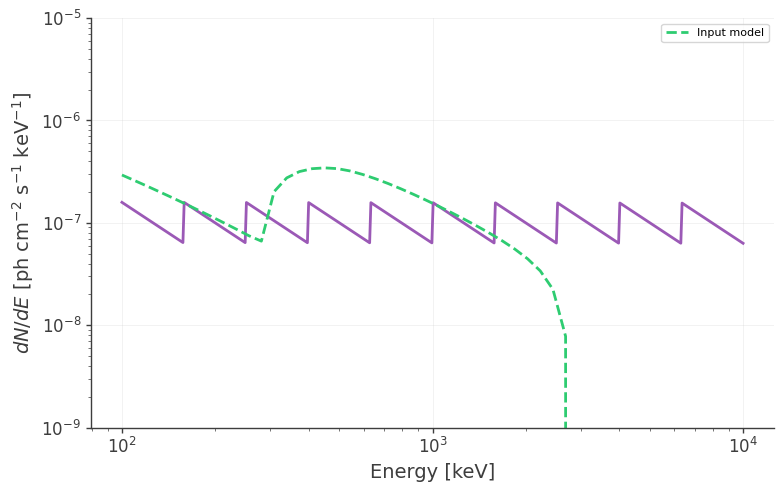

In [14]:
%matplotlib inline

# Energy grid in keV
energy = np.geomspace(100.0, 1.0e4, 500)

# Evaluate the astromodels spectral function
flux = spec_inflight(energy)


print("energy[0] =", energy[0])
print("SED range  =", spec_inflight.bin_edges[0], spec_inflight.bin_edges[-1])

flux = spec_inflight(energy)

print("flux[0] =", flux[0])
print("max flux =", np.max(flux))
print("nonzero points =", np.count_nonzero(flux))

# Convert astropy quantities to arrays if necessary
energy_plot = getattr(energy, "value", energy)
flux_plot = getattr(flux, "value", flux)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    energy_plot,
    flux_plot,
    linewidth=2,
)

df = pd.read_csv(
    "Positrons_In_Flight_Annihilation_spec.dat",
    sep=r"\s+",
    skiprows=5,
    names=["dummy", "energy", "flux"],
)

ax.plot(
    df["energy"],
   df["flux"],
    label="Input model",
    linestyle="--",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel(
    r"$dN/dE$ [ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$]"
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

plt.ylim(1e-9,1e-5)
plt.show()

Define model

In [15]:
model = Model(inflight_src)
model.display()

Model summary:
==============

                  N
Point sources     0
Extended sources  1
Particle sources  0

Free parameters (10):
--------------------

               value min_value max_value            unit
in_flight...K0   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K1   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K2   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K3   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K4   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K5   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K6   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K7   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K8   0.0       0.0      0.01  keV-1 s-1 cm-2
in_flight...K9   0.0       0.0      0.01  keV-1 s-1 cm-2

Fixed parameters (44):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

## Setup and perform fit
Setup background parameter, extended source , orientation file and the LH fit

In [16]:
#open the orientation file
sc_orientation = SpacecraftHistory.open(ori_file)

#open the extended source response
dr = ExtendedSourceResponse.open(psr_file)


bkg_dist = {"total_bg":total_bg.binned_data.project('Em', 'Phi', 'PsiChi')}

# Workaround to avoid inf values. Out bkg should be smooth, but currently it's not.
# Reproduces results before refactoring. It's not _exactly_ the same, since this fudge value was 1e-12, and
# it was added to the expectation, not the normalized bkg
for bckfile in bkg_dist.keys() :
    bkg_dist[bckfile] += sys.float_info.min

    input_bg_norms = {}

# print input normalization value:
print("input rates:")

for label, hist in bkg_dist.items():

    input_counts = np.sum(hist)

    # np.sum() of a sparse Histogram may return a 0-D sparse.COO object
    if hasattr(input_counts, "todense"):
        input_counts = input_counts.todense()

    input_counts = np.asarray(input_counts).item()

    input_rate = (input_counts/ sc_orientation.cumulative_livetime().to_value(u.s))

    input_bg_norms[label] = input_rate

    print(f"{label}: {input_rate:.6g} Hz")
    
data = EmCDSBinnedData(mock_dataset)
    
bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = False)

# Currently using the same NnuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
    

esr = BinnedThreeMLExtendedSourceResponse(data = data,
                                          precomputed_psr = dr,
                                           
                                           polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                           )

##====


response = BinnedThreeMLModelFolding(data = data, extended_source_response = esr)

like_fun = PoissonLikelihood(data, response, bkg)

cosi = ThreeMLPluginInterface('cosi',
                                  like_fun,
                                  response,
                                  bkg)

cosi.bkg_parameter['total_bg'] = Parameter("total_bg",  # background parameter
                                      25,  # initial value of parameter
                                      unit = u.Hz, 
                                      min_value=0,  # minimum value of parameter
                                      max_value=100,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      )

input rates:
total_bg: 25.6322 Hz


Instantiate the COSI 3ML plugin and perform the fit

### SED Fit

### Choosing the uncertainty calculation

The SED normalizations $K_i$ are constrained to be non-negative. When the likelihood is well approximated by a parabola near its minimum, the HESSE covariance matrix provides a convenient estimate of the parameter uncertainties. In this example, however, the combination of a large absolute negative log-likelihood (NLL; about $10^9$), very small flux normalizations, and parameter bounds can make the numerical HESSE errors unstable even when the fit reports an accurate covariance matrix.

For this reason, the reported SED uncertainties are calculated from direct likelihood crossings rather than from HESSE. For each detected energy bin, the central flux is kept from the stable baseline fit, while the lower and upper errors are obtained by evaluating how the likelihood changes as that bin normalization is moved away from its best-fit value. The scan uses a fixed NLL offset and dimensionless optimizer coordinates so that the calculation remains numerically well scaled. HESSE errors may still appear in the fit output as diagnostics, but they are not used for the plotted error bars or upper limits.

The first fit identifies bins whose normalizations are effectively at the physical lower boundary, $K_i=0$. Those bins are frozen at zero before performing the stable baseline fit. This stable fit defines the central SED fluxes and the nuisance parameters used by the likelihood scans.

`PROFILE_ERRORS=False` and `PROFILE_UPPER_LIMITS=False` provide fast conditional calculations in which the other parameters remain fixed at their stable-fit values. Setting either option to `True` profiles over the nuisance parameters that remain free in the stable baseline fit, such as the background normalization and the other retained SED-bin normalizations. Bins that were frozen at zero remain frozen during profiling. For an upper limit, the bin being tested is the parameter of interest and is allowed to move away from zero, while the other boundary-frozen bins remain fixed. Parameters fixed by the model, such as the morphology and within-bin spectral index, also remain fixed.


In [17]:
# Fast settings for this demonstration. Use True for nuisance profiling.
PROFILE_ERRORS = False
PROFILE_UPPER_LIMITS = False

# Minuit convergence tolerance for the centered scan fits, not a confidence
# level. For validation, repeat with 0.001 and compare interval endpoints.
SCAN_FIT_TOL = 0.01

In [18]:
# Helper function for calculating the TS of each SED bin:

def diagnose_sed_bins(
    like,
    spec,
    initial_free_paths,
    ts_threshold=4.0,
):
    """
    Calculate the profile-likelihood TS of each SED bin.

    For each bin i:

        TS_i = 2 * [NLL(K_i = 0) - NLL_full]

    The supplied nuisance parameters are re-optimized under the
    K_i = 0 hypothesis, except K_i itself.

    Parameters
    ----------
    like : JointLikelihood
        Result of the fit with all SED bins free.

    spec : BinnedSED
        Fitted SED spectral model.

    initial_free_paths : set
        Parameter paths to profile as nuisance parameters.

    ts_threshold : float or None, optional
        Bins with TS < ts_threshold are classified as weak.
        Default is 4.0. If None, TS values are calculated but
        no bins are classified as weak.

    Returns
    -------
    weak_bins : list
        SED-bin indices classified as weak.

    diagnostics : pandas.DataFrame
        Best-fit normalization and TS for every SED bin.
    """

    if ts_threshold is not None and ts_threshold < 0:
        raise ValueError("ts_threshold must be >= 0 or None.")

    parameters = list(
        like.likelihood_model.parameters.values()
    )

    # Save the full-fit state
    saved_state = {
        p.path: (float(p.value), bool(p.free))
        for p in parameters
    }

    full_best_values = {
        p.path: float(p.value)
        for p in parameters
    }

    nll_full = float(like.current_minimum)

    rows = []
    weak_bins = []

    try:

        for i in range(spec.n_bins):

            par = getattr(spec, f"K{i}")

            k_best = full_best_values[par.path]

            # --------------------------------------------------
            # Restore full best-fit values and free/fixed states
            # --------------------------------------------------

            for p in parameters:
                p.value = full_best_values[p.path]
                p.free = p.path in initial_free_paths

            # --------------------------------------------------
            # Null hypothesis for this bin: K_i = 0
            # --------------------------------------------------

            par.value = 0.0
            par.free = False

            # Profile all remaining free parameters
            like.fit(
                quiet=True,
                compute_covariance=False,
            )

            nll_null = float(like.current_minimum)

            # --------------------------------------------------
            # Likelihood-ratio TS
            # --------------------------------------------------

            ts_raw = 2.0 * (nll_null - nll_full)

            if ts_raw < -1e-3:
                print(
                    f"Warning: SED bin {i} gave TS={ts_raw:.4g}. "
                    "The null fit found a lower NLL than the full fit."
                )

            # Small negative values can occur from optimizer tolerance
            ts = max(0.0, ts_raw)

            if ts_threshold is None:
                weak = False
            else:
                weak = ts < ts_threshold

            if weak:
                weak_bins.append(i)

            rows.append({
                "bin": i,
                "K_best": k_best,
                "TS": ts,
                "sqrt_TS": np.sqrt(ts),
                "weak": weak,
            })

    finally:

        # Restore the original full-fit state
        for p in parameters:
            value, free = saved_state[p.path]
            p.value = value
            p.free = free

    diagnostics = pd.DataFrame(rows)

    return weak_bins, diagnostics

In [19]:
# ------------------------------------------------------------
# FIRST FIT: all SED bins free
# ------------------------------------------------------------

n_sed_bins = spec_inflight.n_bins

# Save starting normalization values. These are also used to define
# the numerical tolerance for identifying bins effectively at K = 0.
initial_k_values = {}

for i in range(n_sed_bins):

    par = getattr(spec_inflight, f"K{i}")

    initial_k_values[i] = float(par.value)
    par.free = True


like_initial = JointLikelihood(
    model,
    DataList(cosi),
)

like_initial.fit(quiet=False)

print("\nInitial Minuit status:")
print(like_initial.minimizer.minuit.fmin)


# ------------------------------------------------------------
# Identify SED bins effectively at the lower boundary
# ------------------------------------------------------------

# A bin is considered effectively at zero if its fitted
# normalization is below this fraction of its starting value.
BOUNDARY_REL_TOL = 1e-3

boundary_bins = []

for i in range(n_sed_bins):

    par = getattr(spec_inflight, f"K{i}")

    value = float(par.value)
    lower = par.min_value

    if lower is None:
        continue

    lower = float(lower)

    tolerance = BOUNDARY_REL_TOL * initial_k_values[i]

    at_lower_boundary = value <= lower + tolerance

    if at_lower_boundary:
        boundary_bins.append(i)

    print(
        f"SED bin {i}: "
        f"K = {value:.5e}, "
        f"boundary threshold = {lower + tolerance:.5e}, "
        f"at boundary = {at_lower_boundary}"
    )


print("\nSED bins effectively at lower boundary:")
print(boundary_bins)


# ------------------------------------------------------------
# Freeze only bins effectively at the lower boundary
# ------------------------------------------------------------

freeze_binned_sed_bins(
    spec_inflight,
    boundary_bins,
)


# ------------------------------------------------------------
# SECOND FIT: stable baseline fit
# ------------------------------------------------------------

like = JointLikelihood(
    model,
    DataList(cosi),
)

like.fit(quiet=False)

print("\nFinal Minuit status:")
print(like.minimizer.minuit.fmin)


# ------------------------------------------------------------
# Save parameters free in the final baseline fit
# ------------------------------------------------------------

stable_free_paths = set(
    like.likelihood_model.free_parameters.keys()
)


# ------------------------------------------------------------
# Save final baseline state
# ------------------------------------------------------------

parameters = list(
    like.likelihood_model.parameters.values()
)

baseline_state = {
    p.path: (float(p.value), bool(p.free))
    for p in parameters
}

baseline_values = {
    p.path: float(p.value)
    for p in parameters
}

nll_baseline = float(like.current_minimum)


# ------------------------------------------------------------
# Save final SED values and HESSE errors for diagnostics only
# The plotted errors are replaced by direct likelihood intervals below.
# ------------------------------------------------------------

final_flux = np.full(n_sed_bins, np.nan)
final_flux_err = np.full(n_sed_bins, np.nan)

for i in range(n_sed_bins):

    par = getattr(spec_inflight, f"K{i}")

    final_flux[i] = float(par.value)

    if par.free:

        minuit_name = par.path.replace(".", "_")

        final_flux_err[i] = float(
            like.minimizer.minuit.errors[minuit_name]
        )


# Retain the old HESSE values for comparison; do not use them for the plot.
# Direct scan errors below have separate lower and upper values.
sed_flux = final_flux.copy()
sed_flux_err = final_flux_err.copy()


# ------------------------------------------------------------
# Calculate TS for every SED bin
# ------------------------------------------------------------

# Bins below this TS will be reported as upper limits.
TS_THRESHOLD = 1.0

# True:
#   Profile all parameters that were free in the stable fit.
#
# False:
#   Keep all other parameters fixed at their stable-fit values.
PROFILE_TS = False

rows = []
weak_bins = []


# Use a separate JointLikelihood object for the TS calculations
like_ts = JointLikelihood(
    model,
    DataList(cosi),
)


def restore_baseline():
    """Restore parameter values and free/fixed states from stable fit."""

    for p in parameters:

        value, free = baseline_state[p.path]

        p.value = value
        p.free = free


def set_ts_configuration(par, poi_free):
    """
    Set the free/fixed configuration for a TS calculation.

    PROFILE_TS=True:
        Re-free parameters that were free in the stable fit.

    PROFILE_TS=False:
        Fix all parameters except the SED bin being tested.
    """

    if PROFILE_TS:

        for p in parameters:
            p.free = p.path in stable_free_paths

    else:

        for p in parameters:
            p.free = False

    par.free = poi_free


try:

    for i in range(n_sed_bins):

        par = getattr(spec_inflight, f"K{i}")

        restore_baseline()


        # --------------------------------------------------------
        # Case 1:
        # Bin was free in the stable fit.
        #
        # Stable fit = alternative hypothesis.
        # Evaluate the null hypothesis K_i = 0.
        # --------------------------------------------------------

        if par.path in stable_free_paths:

            k_best = baseline_values[par.path]
            nll_alt = nll_baseline

            set_ts_configuration(
                par,
                poi_free=False,
            )

            par.value = 0.0

            like_ts.fit(
                quiet=True,
                compute_covariance=False,
            )

            nll_null = float(like_ts.current_minimum)


        # --------------------------------------------------------
        # Case 2:
        # Bin was frozen at zero in the stable fit.
        #
        # Stable fit = null hypothesis.
        # Temporarily free K_i to fit the alternative.
        # --------------------------------------------------------

        else:

            nll_null = nll_baseline

            restore_baseline()

            # Start away from zero
            par.value = initial_k_values[i]

            set_ts_configuration(
                par,
                poi_free=True,
            )

            like_ts.fit(
                quiet=True,
                compute_covariance=False,
            )

            nll_alt = float(like_ts.current_minimum)
            k_best = float(par.value)


        # --------------------------------------------------------
        # Likelihood-ratio TS
        # --------------------------------------------------------

        ts_raw = 2.0 * (nll_null - nll_alt)

        if ts_raw < -1e-3:

            print(
                f"Warning: SED bin {i} gave TS = {ts_raw:.4g}. "
                "Check convergence of the corresponding fit."
            )

        ts = max(0.0, ts_raw)

        if TS_THRESHOLD is None:
            weak = False
        else:
            weak = ts < TS_THRESHOLD

        if weak:
            weak_bins.append(i)

        rows.append({
            "bin": i,
            "K_best": k_best,
            "TS": ts,
            "sqrt_TS": np.sqrt(ts),
            "weak": weak,
            "boundary_frozen": i in boundary_bins,
        })


finally:

    restore_baseline()


# ------------------------------------------------------------
# Diagnostics table
# ------------------------------------------------------------

sed_diagnostics = pd.DataFrame(rows)

print(
    "\nSED TS calculation:",
    "profiled" if PROFILE_TS else "other parameters fixed",
)

print("\nSED diagnostics:")
print(sed_diagnostics)

if TS_THRESHOLD is not None:

    print(
        f"\nBins reported as upper limits "
        f"(TS < {TS_THRESHOLD}):"
    )

    print(weak_bins)

14:15:21 INFO      set the minimizer to minuit                                             ]8;id=335503;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=185511;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

... Reading Extended source response ...
... Reading Extended source response ...
--> done (source name : in_flight)
--> done (source name : in_flight)
... Convolving spatial morphology with extended-source response ...
... Convolving spatial morphology with extended-source response ...
--> spatial response convolution done
--> spatial response convolution done


14:17:05 WARNING   96.88 percent of samples have been thrown away because they failed the  ]8;id=484281;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=21687;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

,result,unit
parameter,,
in_flight.spectrum.main.BinnedSED_10_0.K0,(0 +/- 5) x 10^-6,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K1,(1 +/- 10) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K2,(2 +/- 4) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K3,(3.5 +/- 1.9) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K4,(2.3 +/- 1.0) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K5,(1.2 +/- 0.6) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K6,(5 +/- 4) x 10^-8,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K7,(0.5 +/- 2.8) x 10^-8,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10_0.K8,(0.0 +/- 1.3) x 10^-9,1 / (keV s cm2)


...

         WARNING   There is no free parameter in the current model                          ]8;id=209604;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=53166;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#270\270]8;;\

         WARNING   There is no free parameter in the current model                          ]8;id=170082;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=277304;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#270\270]8;;\

         WARNING   There is no free parameter in the current model                          ]8;id=620680;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=612386;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#270\270]8;;\

         WARNING   There is no free parameter in the current model                          ]8;id=609316;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=332666;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#270\270]8;;\


SED TS calculation: other parameters fixed

SED diagnostics:
   bin        K_best        TS   sqrt_TS   weak  boundary_frozen
0    0  3.353897e-07  0.003896  0.062420   True            False
1    1  1.038057e-07  0.011118  0.105444   True            False
2    2  2.463200e-07  0.484544  0.696092   True            False
3    3  3.469160e-07  3.949615  1.987364  False            False
4    4  2.214707e-07  5.425765  2.329327  False            False
5    5  1.134184e-07  3.714482  1.927299  False            False
6    6  4.723970e-08  1.529805  1.236853  False            False
7    7  8.928353e-10  0.000000  0.000000   True            False
8    8  5.111633e-14  0.000000  0.000000   True             True
9    9  1.126876e-16  0.000000  0.000000   True             True

Bins reported as upper limits (TS < 1.0):
[0, 1, 2, 7, 8, 9]


### Detected-bin errors from likelihood crossings

For each bin that is not classified as an upper limit, the central flux value is taken from the stable baseline fit. The likelihood scan is then used only to determine the uncertainty by finding the lower and upper flux values satisfying

$$
\mathrm{NLL}(K_i)-\mathrm{NLL}_{\min}=0.5.
$$

Here NLL is the negative log-likelihood. For a detected bin, $\mathrm{NLL}_{\min}$ should correspond to the same minimum as the stable baseline fit. The scan re-minimizes this reference point internally using the same scaled likelihood calculation used for the interval, so its best-fit $K_i$ and minimum NLL should reproduce the stable-fit values within the optimizer tolerance. The diagnostic table below prints both differences explicitly. A noticeable mismatch is a sign to inspect convergence or tighten `SCAN_FIT_TOL` before using the interval.

For one parameter, $\Delta\mathrm{NLL}=0.5$ is the usual likelihood criterion for a nominal $1\sigma$ interval. Finding the two crossings separately allows the lower and upper uncertainties to be asymmetric.

With `PROFILE_ERRORS=False`, the interval is conditional: only $K_i$ is varied while the other parameters are held at their stable-fit values. With `PROFILE_ERRORS=True`, the background and the other parameters that remain free in the stable baseline fit are re-optimized at every trial value of $K_i$. This profiles over their correlations with the SED bin of interest. Bins that were frozen at $K=0$ remain frozen and are not reintroduced into the fit.

In [20]:
# Likelihood crossings, rather than HESSE errors, determine the intervals.
from iminuit import Minuit
from scipy.optimize import brentq


class SEDLikelihoodScan:
    """Conditional (fast) or nuisance-profiled likelihood for one SED bin.

    The original JointLikelihood/minimizer and parameter state are preserved.
    Profiling uses the explicitly supplied nuisance-parameter paths. Parameters
    frozen at zero remain fixed unless that bin is the parameter of interest.
    Morphology and spectral index remain fixed by design.
    """

    def __init__(self, like, spec, bin_index, free_paths, profile=False,
                 fit_tol=0.01, nll_check_tol=1e-3):
        self.like = like
        self.parameters = dict(like.likelihood_model.parameters)
        self.poi = getattr(spec, f"K{bin_index}")
        self.profile = bool(profile)
        self.fit_tol = fit_tol
        self.nll_check_tol = nll_check_tol
        self.saved = {path: float(p.value)
                      for path, p in self.parameters.items()}
        selected = set(free_paths) if profile else set()
        selected.add(self.poi.path)
        unknown = selected - self.parameters.keys()
        if unknown:
            raise ValueError(f"Unknown parameter paths: {unknown}")
        self.paths = [path for path in self.parameters if path in selected]
        # Dimensionless optimizer coordinates keep small fluxes manageable.
        # These scales/steps are initialization choices, NOT error estimates.
        self.scales = {
            path: max(abs(self.saved[path]),
                      abs(float(self.parameters[path].delta)), 1e-12)
            for path in self.paths
        }
        self.scale = self.scales[self.poi.path]
        # Raw NLL at the supplied stable-fit state. This fixed value is used
        # as the numerical offset throughout the scan.
        self.reference_nll_raw = self._raw_nll()
        self.offset = self.reference_nll_raw
        self.nll_best, self.best_values = self._fit(None, self.saved)
        self.nll_best_raw = self.offset + self.nll_best
        self.k_best = self.best_values[self.poi.path]
        self.trace = {}  # Actual evaluated fluxes and Delta NLL, for inspection.

    def _raw_nll(self):
        # Same direct likelihood evaluation used by the original UL helper.
        nll = -float(sum(dataset.inner_fit()
                         for dataset in self.like.data_list.values()))
        if not np.isfinite(nll):
            raise RuntimeError("Non-finite likelihood during the SED scan.")
        return nll

    def _fit(self, fixed_flux, starting_values):
        """Refit only the selected parameters; return a shifted NLL."""
        paths = [path for path in self.paths
                 if fixed_flux is None or path != self.poi.path]
        try:
            for path, value in starting_values.items():
                self.parameters[path].value = value
            if fixed_flux is not None:
                self.poi.value = float(fixed_flux)

            if paths:
                def objective(*q):
                    for path, value in zip(paths, q):
                        self.parameters[path].value = value * self.scales[path]
                    return self._raw_nll() - self.offset

                m = Minuit(objective,
                           *[starting_values[path] / self.scales[path]
                             for path in paths],
                           name=[f"q{i}" for i in range(len(paths))])
                m.errordef = Minuit.LIKELIHOOD
                m.tol = self.fit_tol
                for j, path in enumerate(paths):
                    p = self.parameters[path]
                    scale = self.scales[path]
                    m.limits[j] = (
                        None if p.min_value is None else float(p.min_value)/scale,
                        None if p.max_value is None else float(p.max_value)/scale,
                    )
                    m.errors[j] = np.clip(abs(float(p.delta))/scale, 0.01, 1.0)
                m.migrad(ncall=20000)
                if not m.valid:
                    m.strategy = 2
                    m.migrad(ncall=20000)
                if not m.valid or m.fmin.has_reached_call_limit:
                    raise RuntimeError(
                        "Profile fit did not converge; inspect the fit before "
                        "using its interval. No HESSE fallback is substituted."
                    )
                # Explicitly restore the optimizer's solution before evaluation.
                for j, path in enumerate(paths):
                    self.parameters[path].value = m.values[j] * self.scales[path]

            nll = self._raw_nll() - self.offset
            values = {path: float(p.value)
                      for path, p in self.parameters.items()}
            return nll, values
        finally:
            for path, value in self.saved.items():
                self.parameters[path].value = value

    def delta_nll(self, flux):
        flux = float(flux)
        if flux not in self.trace:
            nll, _ = self._fit(flux, self.best_values)
            delta = nll - self.nll_best
            if delta < -self.nll_check_tol:
                raise RuntimeError(
                    f"A scan found a better minimum (Delta NLL={delta:.4g}). "
                    "Refit the baseline with tighter tolerance before continuing."
                )
            self.trace[flux] = delta
        return self.trace[flux]

    def crossing(self, direction, delta_nll=0.5):
        """Return (endpoint, status), solving in dimensionless flux units.

        A physical bound reached before the target is labelled explicitly;
        it is not misreported as a likelihood crossing.
        """
        if direction not in (-1, 1) or delta_nll <= 0:
            raise ValueError("direction must be +/-1 and delta_nll positive.")
        bound = self.poi.min_value if direction < 0 else self.poi.max_value
        q_bound = None if bound is None else float(bound)/self.scale
        q_best = self.k_best/self.scale
        if q_bound is not None and abs(q_bound-q_best) < 1e-12:
            return float(bound), "parameter_bound"

        def root(q):
            return self.delta_nll(q*self.scale) - delta_nll

        # No dependence on the potentially unstable HESSE uncertainty.
        step = max(0.1, 0.25*abs(q_best))
        for _ in range(60):
            q = q_best + direction*step
            if q_bound is not None:
                q = max(q, q_bound) if direction < 0 else min(q, q_bound)
            value = root(q)
            if value >= 0:
                endpoint = brentq(root, min(q, q_best), max(q, q_best),
                                  xtol=1e-7, rtol=1e-6, maxiter=100)*self.scale
                if abs(self.delta_nll(endpoint)-delta_nll) > 5e-3:
                    raise RuntimeError("Unstable likelihood crossing; inspect scan.")
                return float(endpoint), "crossing"
            if q_bound is not None and q == q_bound:
                return float(bound), "parameter_bound"
            step *= 2.0
        raise RuntimeError("Could not bracket a likelihood crossing.")

    def interval68(self):
        low, low_status = self.crossing(-1, 0.5)
        high, high_status = self.crossing(+1, 0.5)
        return {
            "best": self.k_best, "low": low, "high": high,
            "err_low": self.k_best-low, "err_high": high-self.k_best,
            "low_status": low_status, "high_status": high_status,
        }

    def upper_limit95(self):
        # Nominal one-sided 95% likelihood threshold: 2*Delta NLL = 2.705543.
        upper, status = self.crossing(+1, 2.705543/2)
        if status != "crossing":
            raise RuntimeError("95% UL hits the imposed upper bound; inspect bounds.")
        return upper


In [21]:
# Original HESSE values remain in sed_flux_err for diagnostics only.
sed_err_low = np.full(n_sed_bins, np.nan)
sed_err_high = np.full(n_sed_bins, np.nan)
sed_low_status = np.full(n_sed_bins, "upper_limit", dtype=object)
sed_high_status = np.full(n_sed_bins, "upper_limit", dtype=object)
sed_error_scans = {}
scan_minimum_rows = []

for i in range(n_sed_bins):
    if i in weak_bins:
        continue

    scan = SEDLikelihoodScan(
        like, spec_inflight, i,
        free_paths=stable_free_paths,
        profile=PROFILE_ERRORS,
        fit_tol=SCAN_FIT_TOL,
    )
    interval = scan.interval68()
    sed_error_scans[i] = scan

    # Keep the central SED flux from the stable baseline fit.
    # The likelihood scan is used only to determine the uncertainty.
    sed_err_low[i] = interval["err_low"]
    sed_err_high[i] = interval["err_high"]
    sed_low_status[i] = interval["low_status"]
    sed_high_status[i] = interval["high_status"]

    # For a detected bin, the scan minimum should reproduce the stable-fit
    # minimum. Record both differences explicitly as a convergence diagnostic.
    scan_minimum_rows.append({
        "bin": i,
        "K_stable": sed_flux[i],
        "K_scan_min": interval["best"],
        "delta_K": interval["best"] - sed_flux[i],
        "NLL_stable": scan.reference_nll_raw,
        "NLL_scan_min": scan.nll_best_raw,
        "delta_NLL_min": scan.nll_best_raw - scan.reference_nll_raw,
    })

    print(
        f"SED bin {i}: K = {sed_flux[i]:.5e} "
        f"-{sed_err_low[i]:.5e} / +{sed_err_high[i]:.5e}; "
        f"profiled={PROFILE_ERRORS}; "
        f"endpoints={sed_low_status[i]}, {sed_high_status[i]}"
    )


# The differences below should be close to zero within the optimizer tolerance.
scan_minimum_diagnostics = pd.DataFrame(scan_minimum_rows)

print("\nDetected-bin scan minimum diagnostics:")
print(scan_minimum_diagnostics.to_string(index=False))


SED bin 3: K = 3.46916e-07 -1.75252e-07 / +1.75487e-07; profiled=False; endpoints=crossing, crossing
SED bin 4: K = 2.21471e-07 -9.59002e-08 / +9.59317e-08; profiled=False; endpoints=crossing, crossing
SED bin 5: K = 1.13418e-07 -5.92690e-08 / +5.93029e-08; profiled=False; endpoints=crossing, crossing
SED bin 6: K = 4.72397e-08 -3.84591e-08 / +3.84810e-08; profiled=False; endpoints=crossing, crossing

Detected-bin scan minimum diagnostics:
 bin     K_stable   K_scan_min      delta_K    NLL_stable  NLL_scan_min  delta_NLL_min
   3 3.469160e-07 3.483156e-07 1.399659e-09 -1.069049e+09 -1.069049e+09      -0.000036
   4 2.214707e-07 2.233179e-07 1.847244e-09 -1.069049e+09 -1.069049e+09      -0.000184
   5 1.134184e-07 1.142068e-07 7.883572e-10 -1.069049e+09 -1.069049e+09      -0.000089
   6 4.723970e-08 4.756576e-08 3.260661e-10 -1.069049e+09 -1.069049e+09      -0.000036


## Calculate upper limits and save SED

For bins classified as weak, the notebook calculates a nominal one-sided 95% upper limit from the likelihood crossing

$$
2\left[\mathrm{NLL}(K_{i,\mathrm{UL}})-\mathrm{NLL}_{\min}\right]=2.705543.
$$

The crossing is found directly from the likelihood and does not depend on a HESSE error.

With `PROFILE_UPPER_LIMITS=False`, all other parameters are held fixed at their stable-fit values. With `PROFILE_UPPER_LIMITS=True`, the nuisance parameters that remain free in the stable baseline fit are re-optimized at each trial flux. If the bin being tested was frozen at zero in the baseline fit, that bin alone is allowed to move above zero because it is the parameter of interest. The other boundary-frozen bins remain fixed at zero.

The value `TS_THRESHOLD=1.0` used here is an illustrative threshold for deciding which bins are displayed as upper limits. For a scientific analysis, the TS calculation and the uncertainty or upper-limit calculation should use a consistent treatment of nuisance parameters, and the threshold should be chosen for the intended analysis.

The saved SED table contains only the quantities needed to reproduce the plot, together with the TS and the fixed within-bin power-law index as basic analysis information. Detailed fit-status and diagnostic quantities are printed in the notebook rather than written to the SED file.


In [22]:
def calculate_sed_bin_ul95(
    like,
    spec,
    bin_index,
    nuisance_paths=None,
    profile_nuisance=False,
):
    """One-sided nominal 95% UL from an explicit likelihood crossing.

    False: fast conditional limit, with other parameters fixed.
    True: refit the supplied stable-fit nuisance parameters at every trial flux.
    The bin being tested is always allowed to vary as the parameter of interest.
    Other bins frozen at zero remain fixed.
    """
    if profile_nuisance and nuisance_paths is None:
        raise ValueError("Supply the stable-fit nuisance parameter paths for profiling.")
    scan = SEDLikelihoodScan(
        like, spec, bin_index,
        free_paths=nuisance_paths or (),
        profile=profile_nuisance,
        fit_tol=SCAN_FIT_TOL,
    )
    return scan.k_best, scan.upper_limit95()


In [24]:
# Calculate upper limits and save SED



# ------------------------------------------------------------
# Calculate likelihood-based ULs for weak bins
# ------------------------------------------------------------

sed_ul95 = {}

for i in weak_bins:

    k_best, ul95 = calculate_sed_bin_ul95(
        like=like,
        spec=spec_inflight,
        bin_index=i,
        # Profile only nuisance parameters retained in the stable baseline fit.
        nuisance_paths=stable_free_paths,
        profile_nuisance=PROFILE_UPPER_LIMITS,
    )

    sed_ul95[i] = ul95

    print(
        f"SED bin {i}: "
        f"best K = {k_best:.5e}, "
        f"TS = {sed_diagnostics.loc[sed_diagnostics['bin'] == i, 'TS'].iloc[0]:.3f}, "
        f"UL95 = {ul95:.5e}"
    )


# ------------------------------------------------------------
# Energy-bin information
# ------------------------------------------------------------

edges = dr.axes["Ei"].edges

if isinstance(edges, u.Quantity):
    edges = edges.to_value(u.keV)

edges = np.asarray(edges, dtype=float)

ei_bin_indices = getattr(
    spec_inflight,
    "_cosipy_ei_bin_indices",
    tuple(range(spec_inflight.n_bins)),
)

energy_lo = np.array([edges[i] for i in ei_bin_indices])
energy_hi = np.array([edges[i + 1] for i in ei_bin_indices])

energy = np.sqrt(energy_lo * energy_hi)

energy_err_low = energy - energy_lo
energy_err_high = energy_hi - energy


# ------------------------------------------------------------
# TS information
# ------------------------------------------------------------

ts_by_bin = (
    sed_diagnostics
    .set_index("bin")["TS"]
    .to_dict()
)


# ------------------------------------------------------------
# Build final SED table
# ------------------------------------------------------------

# Keep the saved file compact: include the quantities needed to reproduce
# the SED plot, plus TS and the fixed within-bin power-law index.
# The saved flux is the value from the stable baseline fit; likelihood scans
# determine only the reported asymmetric uncertainties and upper limits.
rows = []

for i in range(spec_inflight.n_bins):

    is_ul = i in weak_bins
    flux_ul95 = sed_ul95[i] if is_ul else np.nan

    rows.append({
        "energy_keV": energy[i],
        "energy_err_low_keV": energy_err_low[i],
        "energy_err_high_keV": energy_err_high[i],
        "flux": sed_flux[i],
        "flux_err_low_1sigma": sed_err_low[i],
        "flux_err_high_1sigma": sed_err_high[i],
        "flux_ul95": flux_ul95,
        "is_ul": is_ul,
        "TS": ts_by_bin[i],
        "powerlaw_index": float(spec_inflight.bin_shape_parameters(i)["index"].value),
    })


sed = pd.DataFrame(rows)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

sed.to_csv(
    "sed_true_energy.dat",
    sep=" ",
    index=False,
    float_format="%.8e",
    na_rep="nan",
)

print("Saved SED columns:")
print(list(sed.columns))
print(sed)

SED bin 0: best K = 2.80567e-07, TS = 0.004, UL95 = 7.46890e-06
SED bin 1: best K = 9.67944e-08, TS = 0.011, UL95 = 1.60828e-06
SED bin 2: best K = 2.42746e-07, TS = 0.485, UL95 = 8.16198e-07
SED bin 7: best K = 2.44676e-10, TS = 0.000, UL95 = 5.25134e-08
SED bin 8: best K = 8.08853e-15, TS = 0.000, UL95 = 3.06611e-08
SED bin 9: best K = 2.44249e-17, TS = 0.000, UL95 = 6.83728e-09
Saved SED columns:
['energy_keV', 'energy_err_low_keV', 'energy_err_high_keV', 'flux', 'flux_err_low_1sigma', 'flux_err_high_1sigma', 'flux_ul95', 'is_ul', 'TS', 'powerlaw_index']
    energy_keV  energy_err_low_keV  energy_err_high_keV          flux  \
0   125.892414           25.892414            32.596586  3.353897e-07   
1   199.526172           41.037172            51.662828  1.038057e-07   
2   316.227923           65.038923            81.879077  2.463200e-07   
3   501.186989          103.079989           129.770011  3.469160e-07   
4   794.328018          163.371018           205.671982  2.214707e-07  

### Plot SED

0     True
1     True
2     True
3    False
4    False
5    False
6    False
7     True
8     True
9     True
Name: is_ul, dtype: bool


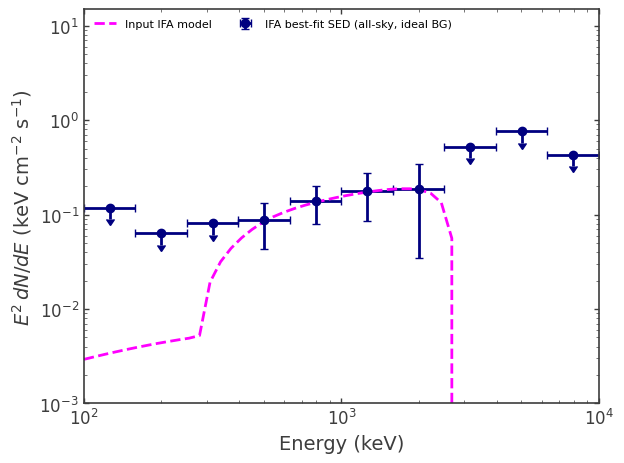

In [25]:
# Plot SED

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Read simulated input spectrum
# ------------------------------------------------------------------


df = pd.read_csv(
    "Positrons_In_Flight_Annihilation_spec.dat",
    sep=r"\s+",
    skiprows=5,
    names=["dummy", "energy", "flux"],
)


# ------------------------------------------------------------------
# Read reconstructed SED
# ------------------------------------------------------------------

sed = pd.read_csv(
    "sed_true_energy.dat",
    sep=r"\s+",
)

print(sed["is_ul"])
ul = sed["is_ul"] == True
det = ~ul

# ------------------------------------------------------------------
# Plot E^2 dN/dE
# ------------------------------------------------------------------

fig, ax = plt.subplots()

# Frame on all four sides
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Ticks on all four sides
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    top=True,
    right=True,
)


# ------------------------------------------------------------------
# Detected SED bins
# ------------------------------------------------------------------

E = sed.loc[det, "energy_keV"].to_numpy()
flux = sed.loc[det, "flux"].to_numpy()
# Lower and upper likelihood errors can differ; preserve that asymmetry.
flux_err = np.vstack([
    sed.loc[det, "flux_err_low_1sigma"].to_numpy(),
    sed.loc[det, "flux_err_high_1sigma"].to_numpy(),
])

xerr_low = sed.loc[det, "energy_err_low_keV"].to_numpy()
xerr_high = sed.loc[det, "energy_err_high_keV"].to_numpy()

y = E**2 * flux
yerr = E**2 * flux_err

ax.errorbar(
    E,
    y,
    xerr=[xerr_low, xerr_high],
    yerr=yerr,
    fmt="o",
    capsize=3,
    color="navy",
    label="IFA best-fit SED (all-sky, ideal BG)",
)


# ------------------------------------------------------------------
# 95% upper limits
# ------------------------------------------------------------------

E_ul = sed.loc[ul, "energy_keV"].to_numpy()
flux_ul = sed.loc[ul, "flux_ul95"].to_numpy()

xerr_low_ul = sed.loc[ul, "energy_err_low_keV"].to_numpy()
xerr_high_ul = sed.loc[ul, "energy_err_high_keV"].to_numpy()

y_ul = E_ul**2 * flux_ul

# yerr here only controls the visual length of the downward UL arrow
ax.errorbar(
    E_ul,
    y_ul,
    xerr=[xerr_low_ul, xerr_high_ul],
    yerr=0.25 * y_ul,
    uplims=True,
    fmt="o",
    capsize=3,
    color="navy",
    label="_nolabel_",
)


# ------------------------------------------------------------------
# Input model
# ------------------------------------------------------------------

ax.plot(
    df["energy"],
    df["energy"]**2 * df["flux"],
    linestyle="--",
    color="magenta",
    label="Input IFA model",
)


# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(
    r"$E^2\,dN/dE$ (keV cm$^{-2}$ s$^{-1}$)"
)

ax.set_xlim(100, 10000)
ax.set_ylim(1e-3, 15)

ax.legend(
    frameon=False,
    ncol=2,
    loc=2,
)

fig.tight_layout()

fig.savefig(
    "true_energy_sed_paper_plot_2.pdf",
)

plt.show()
plt.close(fig)